Imports & Setup

In [2]:
import os
import sys
import json
import numpy as np
import matplotlib.pyplot as plt

# Add project root to path so we can import from src/
sys.path.append("..")

from src.evaluation.visualize import (
    plot_loss_curves,
    plot_predictions,
    plot_model_comparison
)
from src.evaluation.metrics import (
    load_scaler,
    load_trained_model,
    get_predictions,
    inverse_transform_predictions
)
from src.data.dataset import load_processed_data, split_data, create_dataloaders
import yaml

# Load config
with open("../configs/config.yaml", "r") as f:
    config = yaml.safe_load(f)

print("Setup complete!")
print(f"Config loaded: {list(config.keys())}")

Setup complete!
Config loaded: ['data', 'sequence', 'training', 'lstm', 'transformer', 'outputs']


Load Data & Models

In [3]:
data_cfg  = config["data"]
seq_cfg   = config["sequence"]
train_cfg = config["training"]
out_cfg   = config["outputs"]

# Load processed data
data = load_processed_data(f"../{data_cfg['processed_dir']}", data_cfg["ticker"])

# Split chronologically
train_data, val_data, test_data = split_data(
    data, data_cfg["train_ratio"], data_cfg["val_ratio"]
)

# Create DataLoaders
_, _, test_loader = create_dataloaders(
    train_data, val_data, test_data,
    seq_len=seq_cfg["seq_len"],
    forecast_horizon=seq_cfg["forecast_horizon"],
    batch_size=train_cfg["batch_size"]
)

# Load scaler
scaler = load_scaler("../data/processed/scaler.pkl")

print(f"\nTest set: {len(test_data)} days")
print(f"Forecast horizon: {seq_cfg['forecast_horizon']} days")

Loaded processed data: (4090, 16)
Train: 2863 | Val: 613 | Test: 614
Batches — Train: 87 | Val: 17 | Test: 17
Scaler loaded from ../data/processed/scaler.pkl

Test set: 614 days
Forecast horizon: 30 days


c:\Users\Mahnoor\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\base.py:376: InconsistentVersionWarning: Trying to unpickle estimator MinMaxScaler from version 1.5.0 when using version 1.5.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


 Loss Curves

Loss curves saved to ../outputs/plots\loss_curves.png


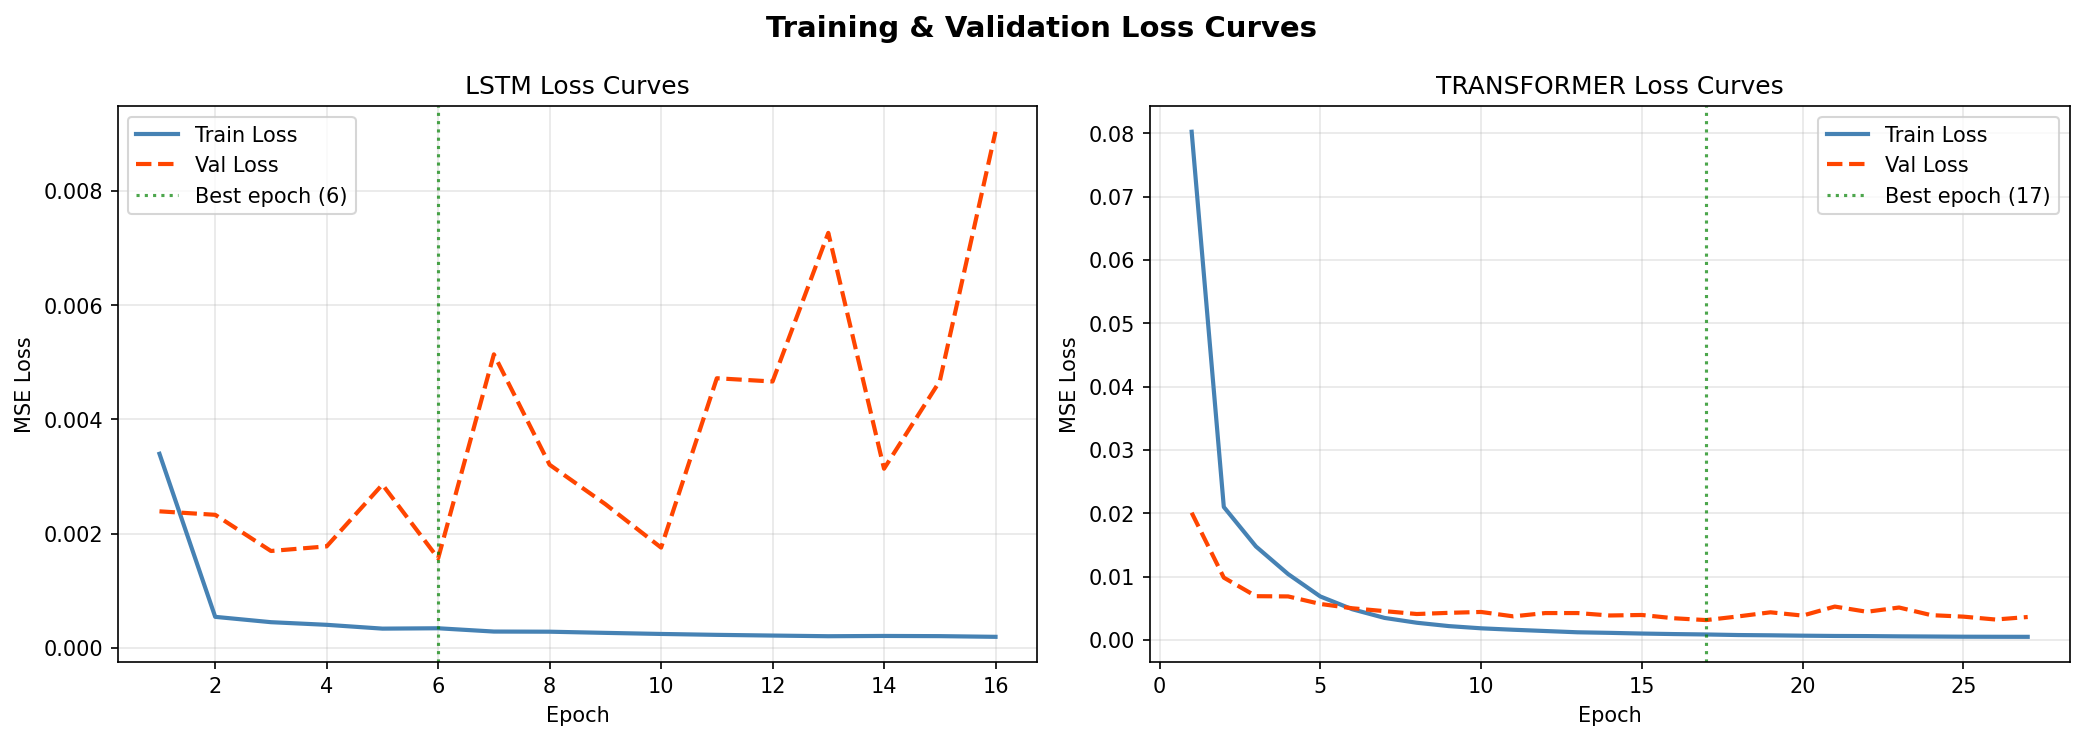

In [4]:
plot_loss_curves(
    results_dir=f"../{out_cfg['results_dir']}",
    plots_dir=f"../{out_cfg['plots_dir']}"
)

# Display inline
from IPython.display import Image
Image(f"../{out_cfg['plots_dir']}/loss_curves.png")

 Load Both Models & Get Predictions

In [5]:
results = {}

for model_type in ["lstm", "transformer"]:
    print(f"Loading {model_type.upper()}...")
    
    # Load trained model
    model = load_trained_model(
        model_type, config, 
        data.shape[1], 
        f"../{out_cfg['model_dir']}"
    )
    
    # Get predictions on test set
    preds, targets = get_predictions(model, test_loader)
    
    # Inverse transform to real dollar prices
    preds_real, targets_real = inverse_transform_predictions(
        preds, targets, scaler, seq_cfg["target_col"]
    )
    
    results[model_type] = {
        "preds_real":   preds_real,
        "targets_real": targets_real
    }
    print(f"{model_type.upper()} predictions shape: {preds_real.shape}")

Loading LSTM...
Loaded lstm weights from ../outputs/models\lstm_best.pth
LSTM predictions shape: (525, 30)
Loading TRANSFORMER...
Loaded transformer weights from ../outputs/models\transformer_best.pth


c:\Users\Mahnoor\OneDrive\Desktop\9-Project Final Year Portfolio\stock-price-prediction\notebooks\..\src\models\transformer.py:120: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer_encoder = nn.TransformerEncoder(


TRANSFORMER predictions shape: (525, 30)


 LSTM Prediction Plots

Prediction plot saved to ../outputs/plots\lstm_predictions.png


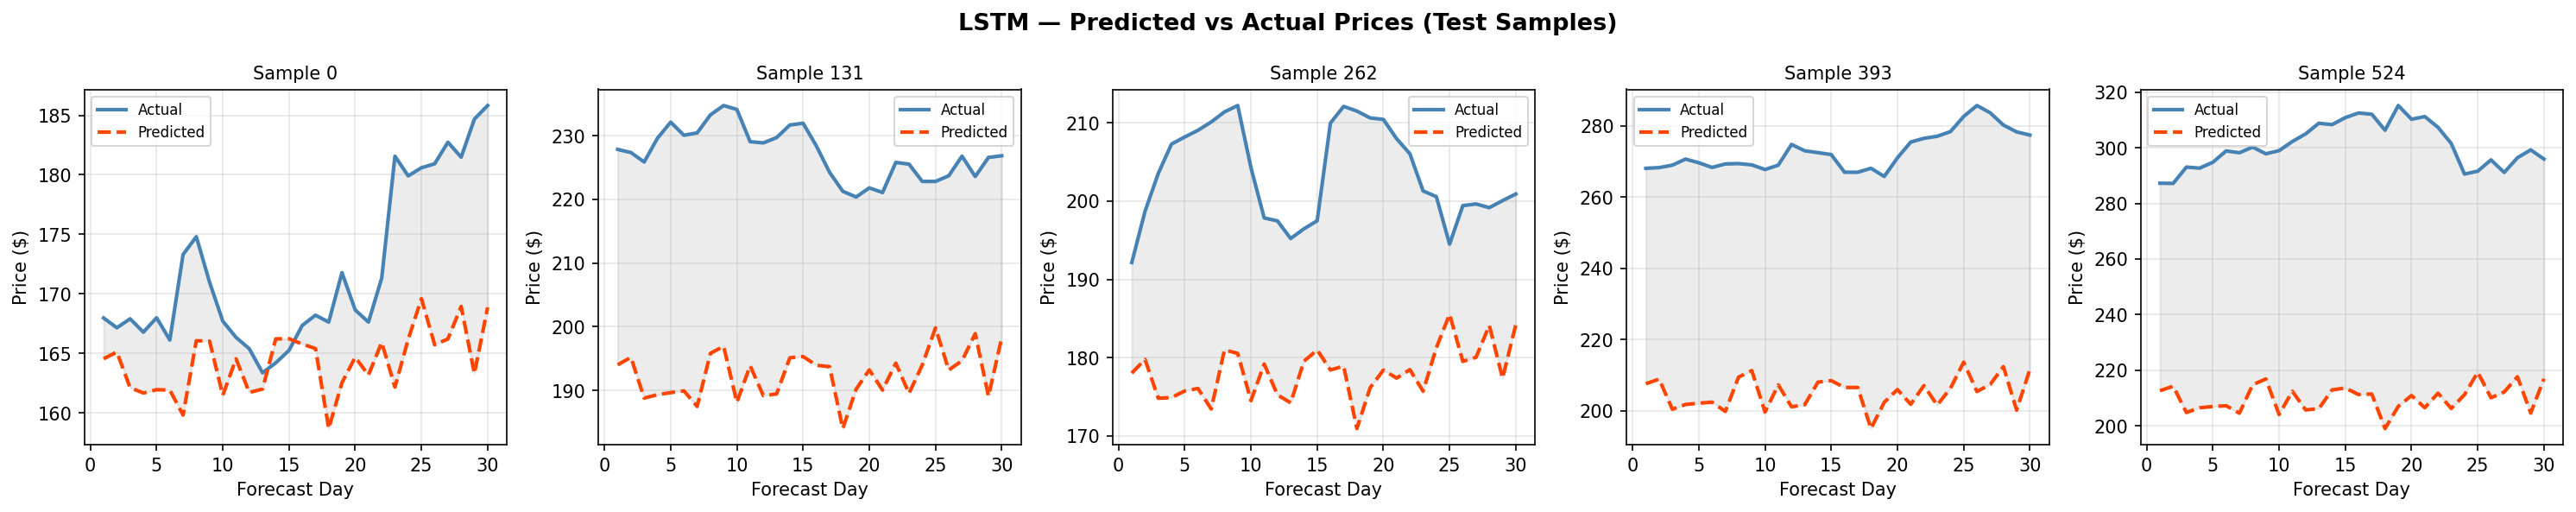

In [6]:
plot_predictions(
    model_type="lstm",
    preds_real=results["lstm"]["preds_real"],
    targets_real=results["lstm"]["targets_real"],
    plots_dir=f"../{out_cfg['plots_dir']}"
)

Image(f"../{out_cfg['plots_dir']}/lstm_predictions.png")

Transformer Prediction Plots

Prediction plot saved to ../outputs/plots\transformer_predictions.png


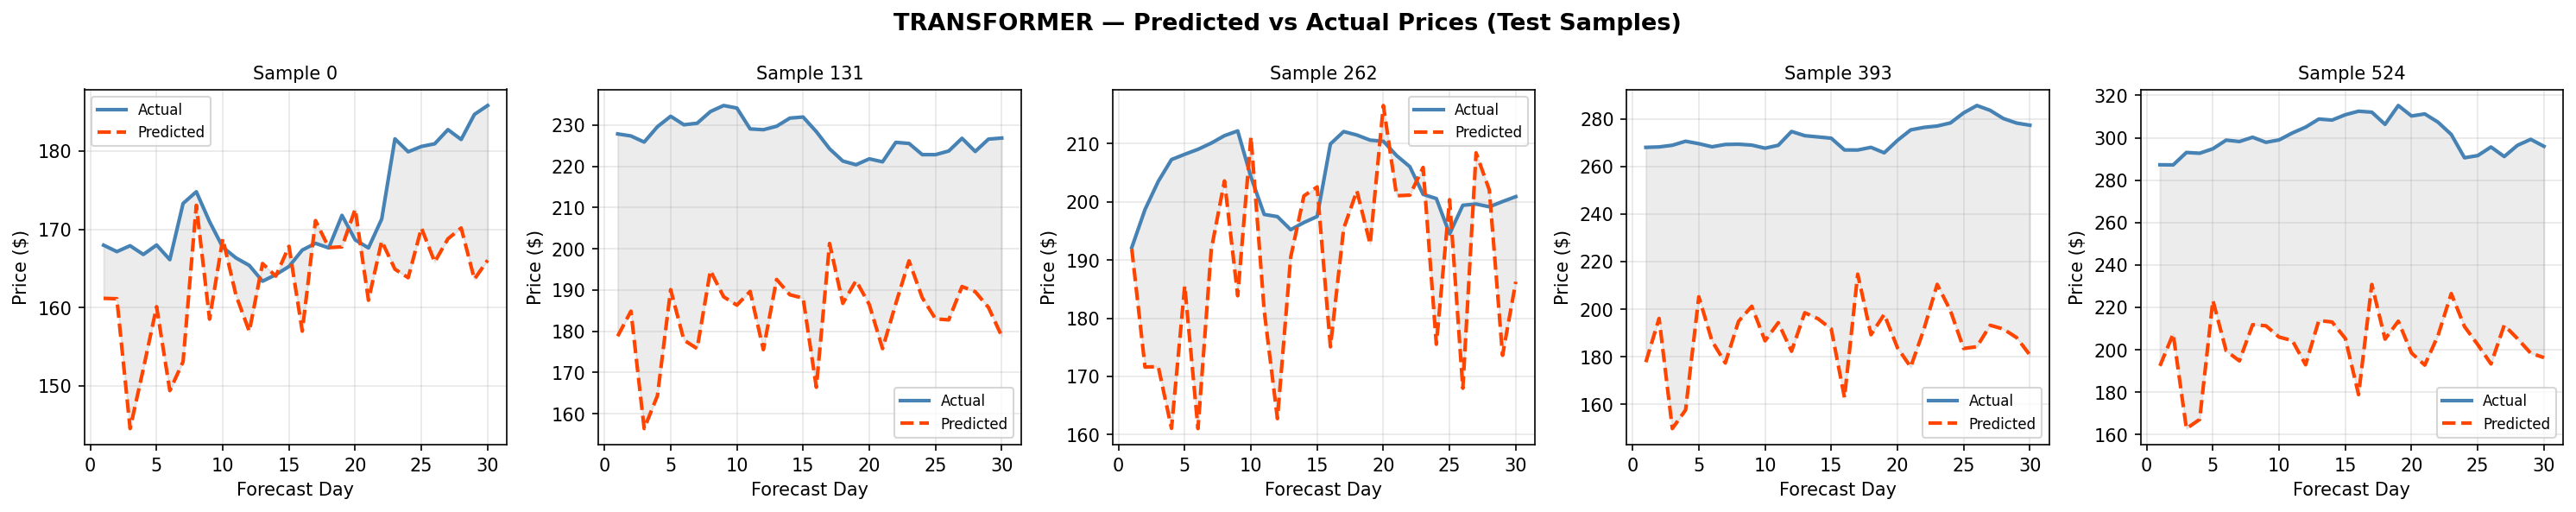

In [7]:
plot_predictions(
    model_type="transformer",
    preds_real=results["transformer"]["preds_real"],
    targets_real=results["transformer"]["targets_real"],
    plots_dir=f"../{out_cfg['plots_dir']}"
)

Image(f"../{out_cfg['plots_dir']}/transformer_predictions.png")

Model Comparison Chart

Comparison plot saved to ../outputs/plots\model_comparison.png


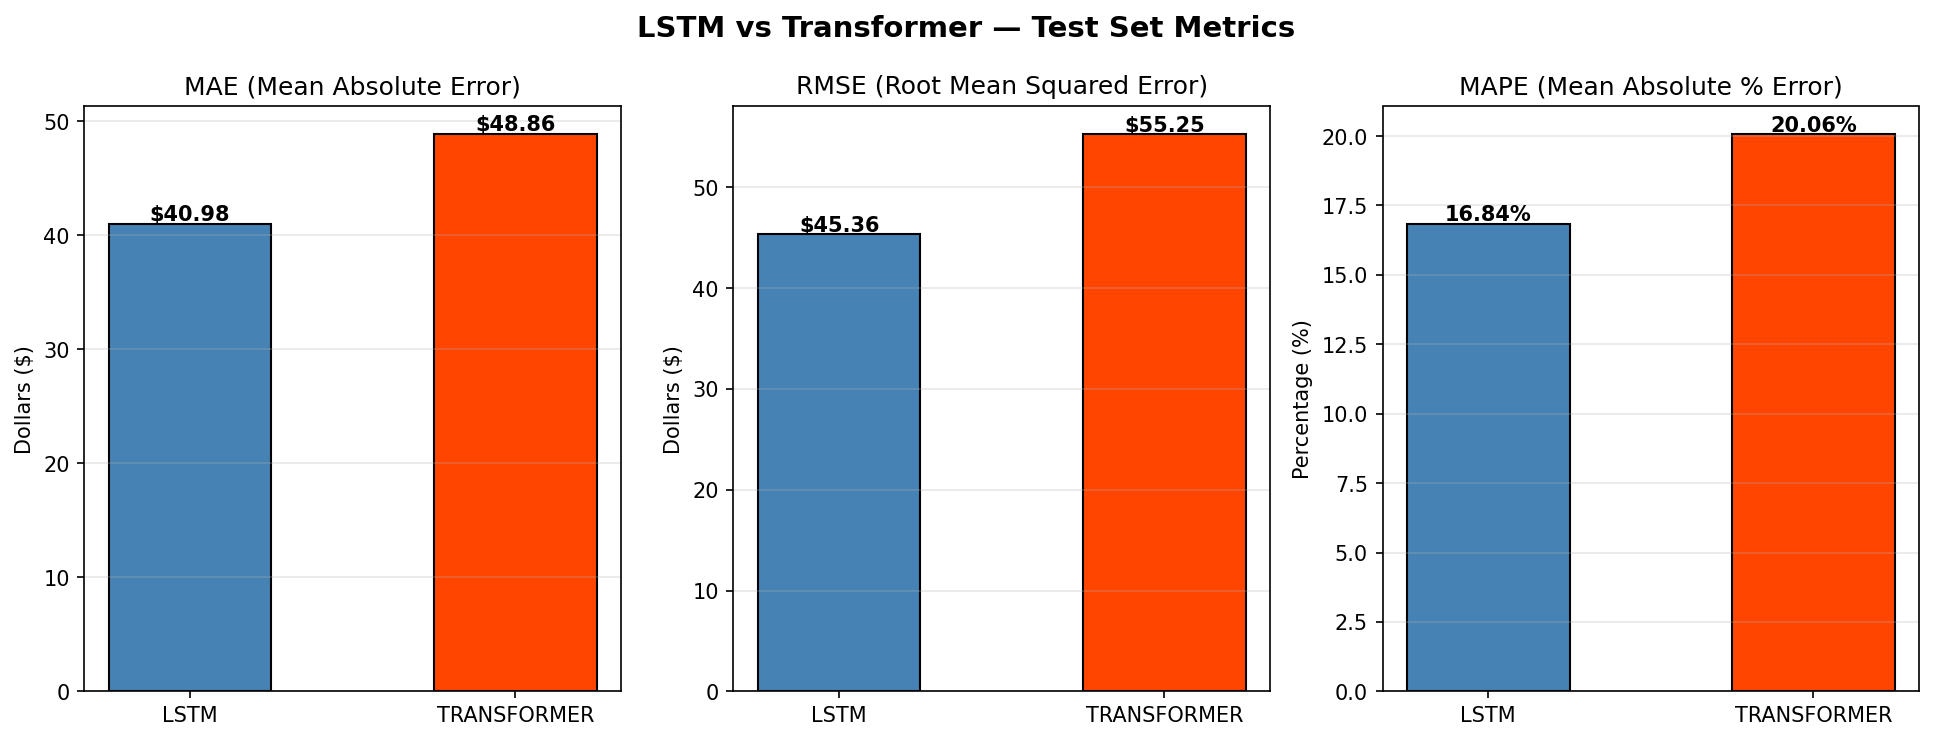

In [8]:
plot_model_comparison(
    metrics_path=f"../{out_cfg['results_dir']}/metrics.json",
    plots_dir=f"../{out_cfg['plots_dir']}"
)

Image(f"../{out_cfg['plots_dir']}/model_comparison.png")

 Metrics Summary Table

In [9]:
with open(f"../{out_cfg['results_dir']}/metrics.json", "r") as f:
    metrics = json.load(f)

print(f"{'='*55}")
print(f"{'Model':<15} {'MAE':>10} {'RMSE':>10} {'MAPE':>10}")
print(f"{'='*55}")
for m in metrics:
    print(f"{m['model'].upper():<15} ${m['MAE']:>9.4f} ${m['RMSE']:>9.4f} {m['MAPE']:>9.2f}%")
print(f"{'='*55}")

# Winner
best = min(metrics, key=lambda x: x["MAE"])
print(f"\nBest model by MAE: {best['model'].upper()}")

Model                  MAE       RMSE       MAPE
LSTM            $  40.9835 $  45.3612     16.84%
TRANSFORMER     $  48.8635 $  55.2517     20.06%

Best model by MAE: LSTM
